In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from PIL import Image
import os
from tqdm import tqdm

# 1. Dataset (Strictly Matched from your fixed folder)
class HybridDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.files = sorted([f for f in os.listdir(root_dir) if f.lower().endswith(('.png', '.jpg'))])
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
    def __len__(self): return len(self.files)
    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root_dir, self.files[idx])).convert("RGB")
        w, h = img.size
        return self.transform(img.crop((0,0,w//2,h))), self.transform(img.crop((w//2,0,w,h)))

# 2. Residual Block for the Bottleneck
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(dim, dim, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(dim)
        )
    def forward(self, x): return x + self.block(x)

# 3. The Frankenstein Generator
class FrankensteinGen(nn.Module):
    def __init__(self):
        super().__init__()
        # Downsampling
        self.down1 = nn.Sequential(nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2))
        self.down2 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.LeakyReLU(0.2))
        self.down3 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.LeakyReLU(0.2))
        
        # Residual Bottleneck (The "Brain")
        self.bottleneck = nn.Sequential(*[ResBlock(256) for _ in range(6)])
        
        # Upsampling with Skip Connections
        self.up1 = nn.Sequential(nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU())
        self.up2 = nn.Sequential(nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU()) # 256 due to concat
        self.final = nn.Sequential(nn.ConvTranspose2d(128, 3, 4, 2, 1), nn.Tanh())

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        bn = self.bottleneck(d3)
        u1 = self.up1(bn)
        u2 = self.up2(torch.cat([u1, d2], 1))
        return self.final(torch.cat([u2, d1], 1))

# 4. PatchGAN Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(6, 64, 4, 2, 1), nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 1, 4, 1, 1)
        )
    def forward(self, x, y): return self.model(torch.cat([x, y], 1))

# 5. Training Logic
device = torch.device("cuda")
gen = nn.DataParallel(FrankensteinGen()).to(device)
disc = nn.DataParallel(Discriminator()).to(device)

opt_g = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = optim.Adam(disc.parameters(), lr=1e-4, betas=(0.5, 0.999))
mse = nn.MSELoss()
l1 = nn.L1Loss()

loader = DataLoader(HybridDataset("gan_stitched"), batch_size=32, shuffle=True)

for epoch in range(50):
    loop = tqdm(loader, desc=f"Epoch {epoch}")
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        
        # Train Disc
        fake = gen(x)
        loss_d = (mse(disc(x, y), torch.ones_like(disc(x, y))) + mse(disc(x, fake.detach()), torch.zeros_like(disc(x, fake.detach())))) / 2
        opt_d.zero_grad(); loss_d.backward(); opt_d.step()
        
        # Train Gen (Hybrid Loss)
        pred = disc(x, fake)
        g_loss = mse(pred, torch.ones_like(pred)) + (l1(fake, y) * 100)
        opt_g.zero_grad(); g_loss.backward(); opt_g.step()
        
        loop.set_postfix(G=g_loss.item(), D=loss_d.item())

torch.save(gen.module.state_dict(), "frankenstein_gan.pth")
print(" Frankenstein is ALIVE!")

Epoch 49: 100%|██████████| 45/45 [00:14<00:00,  3.10it/s, D=0.136, G=27.3] 


 Frankenstein is ALIVE!


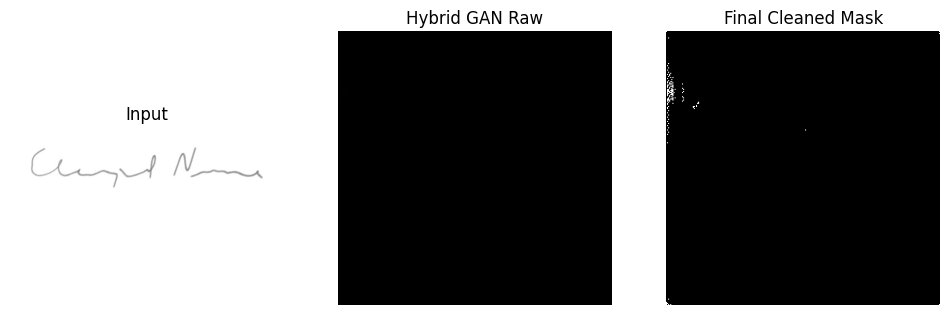

In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import numpy as np

# 1. Load the Frankenstein Architecture
class ResBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(dim, dim, 3, 1, 1, bias=False),
            nn.InstanceNorm2d(dim)
        )
    def forward(self, x): return x + self.block(x)

class FrankensteinGen(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = nn.Sequential(nn.Conv2d(3, 64, 4, 2, 1), nn.LeakyReLU(0.2))
        self.down2 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.LeakyReLU(0.2))
        self.down3 = nn.Sequential(nn.Conv2d(128, 256, 4, 2, 1), nn.InstanceNorm2d(256), nn.LeakyReLU(0.2))
        self.bottleneck = nn.Sequential(*[ResBlock(256) for _ in range(6)])
        self.up1 = nn.Sequential(nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.InstanceNorm2d(128), nn.ReLU())
        self.up2 = nn.Sequential(nn.ConvTranspose2d(256, 64, 4, 2, 1), nn.InstanceNorm2d(64), nn.ReLU())
        self.final = nn.Sequential(nn.ConvTranspose2d(128, 3, 4, 2, 1), nn.Tanh())

    def forward(self, x):
        d1 = self.down1(x); d2 = self.down2(d1); d3 = self.down3(d2)
        bn = self.bottleneck(d3)
        u1 = self.up1(bn)
        u2 = self.up2(torch.cat([u1, d2], 1))
        return self.final(torch.cat([u2, d1], 1))

device = torch.device("cuda")
model = FrankensteinGen().to(device)
model.load_state_dict(torch.load("frankenstein_gan.pth"))
model.eval()

# 2. Inference Function
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def test_frankenstein(image_path):
    img = Image.open(image_path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(x)
        
    out = (out.squeeze(0).cpu() * 0.5 + 0.5).permute(1,2,0).numpy()
    out_uint8 = (out * 255).astype(np.uint8)
    
    # Post-processing
    gray = cv2.cvtColor(out_uint8, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.title("Input"); plt.imshow(img); plt.axis('off')
    plt.subplot(1, 3, 2); plt.title("Hybrid GAN Raw"); plt.imshow(out); plt.axis('off')
    plt.subplot(1, 3, 3); plt.title("Final Cleaned Mask"); plt.imshow(mask, cmap='gray'); plt.axis('off')
    plt.show()

test_frankenstein("cutouts/0039__cf-039-51_cutout.png")